# Breast Ultrasound Image Detection



In [ ]:
# === Config ===
from pathlib import Path
DATA_DIR = Path("/content/drive/MyDrive/MLTRAINING/Dataset_BUSI_with_GT")
IMG_SIZE = (224, 224)
BATCH_SIZE = 8
NUM_EPOCHS = 50
SEED = 42
VAL_SPLIT = 0.2

print(f"Using DATA_DIR={DATA_DIR.resolve()}")


Using DATA_DIR=/content/drive/MyDrive/MLTRAINING/Dataset_BUSI_with_GT


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


IMPORTS

In [ ]:
import os, random, math, json, gc
import numpy as np
import matplotlib.pyplot as plt

# PyTorch (U-Net)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# TF/Keras (EfficientNet features)
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras import layers, models

# Classical ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Image IO
import cv2

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    tf.random.set_seed(seed)

set_seed(SEED)
print("Libraries loaded.")

Libraries loaded.


## Preprocessing
Loads images from `normal/`, `benign/`, `malignant/`. If `*_mask.png` or `*_mask.jpg` exists in the same folder, it will be used for U‑Net segmentation; otherwise, a blank mask is used.

In [ ]:
# data loading
CLASS_NAMES = ["normal","benign","malignant"]
le = LabelEncoder().fit(CLASS_NAMES)

def load_image(path, size):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {path}")
    img = cv2.resize(img, (size[1], size[0]), interpolation=cv2.INTER_AREA)
    return img

def try_load_mask(img_path, size):

    p = Path(img_path)
    candidates = list(p.parent.glob(p.stem.replace("_mask","") + "_mask.*"))
    for c in candidates:
        m = cv2.imread(str(c), cv2.IMREAD_GRAYSCALE)
        if m is not None:
            return cv2.resize(m, (size[1], size[0]), interpolation=cv2.INTER_NEAREST)

    return np.zeros((size[0], size[1]), dtype=np.uint8)     # fallback: empty mask

def collect_dataset(root: Path, size):
    X, M, y = [], [], []
    for cls in CLASS_NAMES:
        d = root/cls
        if not d.exists():
            print(f"Warning: missing folder {d}")
            continue
        for img_path in sorted(list(d.glob("*.png")) + list(d.glob("*.jpg")) + list(d.glob("*.jpeg"))):
            if "_mask" in img_path.name:
                continue
            img = load_image(img_path, size)
            mask = try_load_mask(img_path, size)
            X.append(img)
            M.append(mask)
            y.append(le.transform([cls])[0])
    X = np.array(X, dtype=np.uint8)
    M = (np.array(M, dtype=np.uint8) > 127).astype(np.uint8)  # binary mask
    y = np.array(y, dtype=np.int64)
    return X, M, y

print("Loading dataset...")
X, M, y = collect_dataset(DATA_DIR, IMG_SIZE)
print("Shapes -> X:", X.shape, "M:", M.shape, "y:", y.shape)

Loading dataset...
Shapes -> X: (766, 224, 224) M: (766, 224, 224) y: (766,)


# Train/Val split

In [ ]:

X_train, X_val, M_train, M_val, y_train, y_val = train_test_split(
    X, M, y, test_size=VAL_SPLIT, stratify=y, random_state=SEED)

print("Train:", X_train.shape, M_train.shape, y_train.shape)
print("Val:  ", X_val.shape, M_val.shape, y_val.shape)

Train: (612, 224, 224) (612, 224, 224) (612,)
Val:   (154, 224, 224) (154, 224, 224) (154,)


## Model 1: MultiTask U‑Net (PyTorch)


In [ ]:
# MultiTask U-Net
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = ConvBlock(in_ch, out_ch)
    def forward(self, x1, x2):
        x1 = self.up(x1)
        # pad if needed
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX//2, diffY // 2, diffY - diffY//2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class MultiTaskUNet(nn.Module):
    def __init__(self, in_ch=1, n_classes=3, base=32):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, base)
        self.enc2 = ConvBlock(base, base*2)
        self.enc3 = ConvBlock(base*2, base*4)
        self.enc4 = ConvBlock(base*4, base*8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(base*8, base*16)


        self.up1 = Up(base*16 + base*8, base*8)
        self.up2 = Up(base*8 + base*4, base*4)
        self.up3 = Up(base*4 + base*2, base*2)
        self.up4 = Up(base*2 + base, base)


        self.seg_head = nn.Conv2d(base, 1, 1)

        # Classification head
        self.cls_gap = nn.AdaptiveAvgPool2d(1)
        self.cls_fc = nn.Linear(base*16, n_classes)


    def forward(self, x):
        c1 = self.enc1(x)
        c2 = self.enc2(self.pool(c1))
        c3 = self.enc3(self.pool(c2))
        c4 = self.enc4(self.pool(c3))
        b = self.bottleneck(self.pool(c4))

        x = self.up1(b, c4)
        x = self.up2(x, c3)
        x = self.up3(x, c2)
        x = self.up4(x, c1)

        seg_out = torch.sigmoid(self.seg_head(x))

        cls_out = self.cls_fc(self.cls_gap(b).flatten(1))
        return seg_out, cls_out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet = MultiTaskUNet(in_ch=1, n_classes=len(CLASS_NAMES)).to(device)
print(unet.__class__.__name__, "initialized on", device)

MultiTaskUNet initialized on cuda


Torch dataset & loaders (using shared X/M/y)

In [ ]:

class TorchBUSI(Dataset):
    def __init__(self, X, M, y):
        self.X = X
        self.M = M
        self.y = y
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        img = self.X[i].astype(np.float32)/255.0  # [0,1]
        img = img[None, ...]                      # 1xHxW
        mask = self.M[i].astype(np.float32)[None, ...]
        label = self.y[i]
        return torch.from_numpy(img), torch.from_numpy(mask), torch.tensor(label, dtype=torch.long)

train_ds = TorchBUSI(X_train, M_train, y_train)
val_ds   = TorchBUSI(X_val,   M_val,   y_val)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print("Torch loaders ready.")

Torch loaders ready.


U-NET MODEL

In [ ]:
#  Define U-Net model
unet_model = MultiTaskUNet(in_ch=1, n_classes=3, base=64)  # base=64 for better accuracy
unet_model = unet_model.to(device)

# Dice Loss
def dice_loss(pred, target, smooth=1e-6):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - ((2. * intersection + smooth) / (pred.sum() + target.sum() + smooth))

#  Train U-Net with Dice+BCE Loss
def train_unet(epochs):
    print("=== Training U-Net with Dice+BCE Loss + Scheduler ===")
    model = unet_model
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

    bce_loss = torch.nn.BCELoss()
    ce_loss = torch.nn.CrossEntropyLoss()

    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for imgs, masks, labels in train_loader:
            imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)

            optimizer.zero_grad()
            seg_out, cls_out = model(imgs)

            # Compute losses
            loss_seg = bce_loss(seg_out, masks) + dice_loss(seg_out, masks)
            loss_cls = ce_loss(cls_out, labels)
            loss = loss_seg + loss_cls

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for imgs, masks, labels in val_loader:
                imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)
                seg_out, cls_out = model(imgs)
                loss_seg = bce_loss(seg_out, masks) + dice_loss(seg_out, masks)
                loss_cls = ce_loss(cls_out, labels)
                loss = loss_seg + loss_cls
                val_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        scheduler.step(avg_val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "best_unet.pth")
            print("✅ Saved best model.")

    print("Training complete.")


## Model 2: Pipeline (EfficientNetB0 features + LR / RF / XGB)
Reused the shared images and labels, but convert grayscale to 3‑channel RGB and apply `efficientnet` preprocessing. A single feature extractor drives **three** classifiers. All three will be evaluated and reported.

In [ ]:
# Built TF dataset from shared arrays
def to_rgb(arr):  # (N,H,W) -> (N,H,W,3)
    return np.repeat(arr[...,None], 3, axis=-1)

def make_tf_batches(Xa, ya, batch=BATCH_SIZE, training=False):
    Xrgb = to_rgb(Xa).astype(np.float32)
    Xprep = eff_preprocess(Xrgb)  # EfficientNetB0 preprocessing
    ds = tf.data.Dataset.from_tensor_slices((Xprep, ya))
    if training: ds = ds.shuffle(1000, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

tf_train = make_tf_batches(X_train, y_train, training=True)
tf_val   = make_tf_batches(X_val,   y_val,   training=False)

# Feature extractor
base_model = EfficientNetB0(include_top=False, weights="imagenet", pooling="avg", input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False
print("EfficientNetB0 feature extractor ready.")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 feature extractor ready.


In [ ]:
#  Extract features
def extract_features(ds):
    feats, labs = [], []
    for xb, yb in ds:
        f = base_model(xb, training=False).numpy()
        feats.append(f); labs.append(yb.numpy())
    return np.concatenate(feats, axis=0), np.concatenate(labs, axis=0)

print("Extracting features...")
Xtr_f, ytr_f = extract_features(tf_train)
Xva_f, yva_f = extract_features(tf_val)
print("Feature shapes:", Xtr_f.shape, Xva_f.shape)

Extracting features...
Feature shapes: (612, 1280) (154, 1280)


In [ ]:
# Train classical classifiers
print("Training other Models…")
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=300, random_state=SEED)
xg = xgb.XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, random_state=SEED)

lr.fit(Xtr_f, ytr_f)
rf.fit(Xtr_f, ytr_f)
xg.fit(Xtr_f, ytr_f)
print("Finished training other Models.")

Training other Models…
Finished training other Models.


In [ ]:
# === Evaluate other models ===
from collections import OrderedDict

def eval_classifier(name, clf, Xf, ytrue):
    print(f"Evaluating {name}…")
    yp = clf.predict(Xf)
    acc = accuracy_score(ytrue, yp)
    prec, rec, f1, _ = precision_recall_fscore_support(ytrue, yp, average='weighted', zero_division=0)
    print(f"{name} -> Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")
    return {"model":name, "accuracy":acc, "precision":prec, "recall":rec, "f1":f1}

friend_results = []
friend_results.append(eval_classifier("Logistic Regression", lr, Xva_f, yva_f))
friend_results.append(eval_classifier("Random Forest", rf, Xva_f, yva_f))
friend_results.append(eval_classifier("XGBoost", xg, Xva_f, yva_f))

Evaluating Logistic Regression…
Logistic Regression -> Acc: 0.8442, Prec: 0.8478, Rec: 0.8442, F1: 0.8448
Evaluating Random Forest…
Random Forest -> Acc: 0.7987, Prec: 0.8089, Rec: 0.7987, F1: 0.7939
Evaluating XGBoost…
XGBoost -> Acc: 0.8052, Prec: 0.8057, Rec: 0.8052, F1: 0.8044


# Train + Evaluate U-Net

In [ ]:

train_unet(NUM_EPOCHS)


=== Training U-Net with Dice+BCE Loss + Scheduler ===
Epoch [1/50] Train Loss: 2.2985 | Val Loss: 2.1941
✅ Saved best model.
Epoch [2/50] Train Loss: 1.9756 | Val Loss: 1.8494
✅ Saved best model.
Epoch [3/50] Train Loss: 1.8791 | Val Loss: 1.8848
Epoch [4/50] Train Loss: 1.8256 | Val Loss: 2.0989
Epoch [5/50] Train Loss: 1.7396 | Val Loss: 1.6911
✅ Saved best model.
Epoch [6/50] Train Loss: 1.6512 | Val Loss: 1.5227
✅ Saved best model.
Epoch [7/50] Train Loss: 1.5403 | Val Loss: 1.8720
Epoch [8/50] Train Loss: 1.5375 | Val Loss: 2.3133
Epoch [9/50] Train Loss: 1.4316 | Val Loss: 1.7075
Epoch [10/50] Train Loss: 1.3785 | Val Loss: 1.3260
✅ Saved best model.
Epoch [11/50] Train Loss: 1.3497 | Val Loss: 1.5152
Epoch [12/50] Train Loss: 1.3201 | Val Loss: 1.2941
✅ Saved best model.
Epoch [13/50] Train Loss: 1.2784 | Val Loss: 1.1037
✅ Saved best model.
Epoch [14/50] Train Loss: 1.1858 | Val Loss: 1.6019
Epoch [15/50] Train Loss: 1.1762 | Val Loss: 1.2694
Epoch [16/50] Train Loss: 1.2269 | 

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def eval_unet():
    print(" Evaluating U-Net. . . ")
    model = unet_model
    model.load_state_dict(torch.load("best_unet.pth"))
    model.eval()

    all_preds = []
    all_labels = []


    dice_scores = []    # Optional: Segmentation metric (Dice)

    with torch.no_grad():
        for imgs, masks, labels in test_loader:
            imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)
            seg_out, cls_out = model(imgs)

            # Classification predictions
            preds = torch.argmax(cls_out, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Segmentation Dice (optional)
            pred_mask = (seg_out > 0.5).float()
            dice = 1 - dice_loss(pred_mask, masks)
            dice_scores.append(dice.item())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    avg_dice = sum(dice_scores) / len(dice_scores)

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Dice Score (Segmentation): {avg_dice:.4f}")

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "dice": avg_dice
    }


In [ ]:
test_loader = val_loader
unet_result = eval_unet()

 Evaluating U-Net. . . 
Accuracy: 0.8636
Precision: 0.8428
Recall: 0.8639
F1-score: 0.8524
Dice Score (Segmentation): 0.7263


##PLOTTING


 Evaluating Models 

Evaluating U-Net...
 Evaluating U-Net. . . 
Accuracy: 0.8636
Precision: 0.8428
Recall: 0.8639
F1-score: 0.8524
Dice Score (Segmentation): 0.7263

Evaluating Other Models...

Final metrics (validation set):
U-Net: Acc=0.8636, Prec=0.8428, Rec=0.8639, F1=0.8524
Logistic Regression: Acc=0.8442, Prec=0.8478, Rec=0.8442, F1=0.8448
Random Forest: Acc=0.7987, Prec=0.8089, Rec=0.7987, F1=0.7939
XGBoost: Acc=0.8052, Prec=0.8057, Rec=0.8052, F1=0.8044


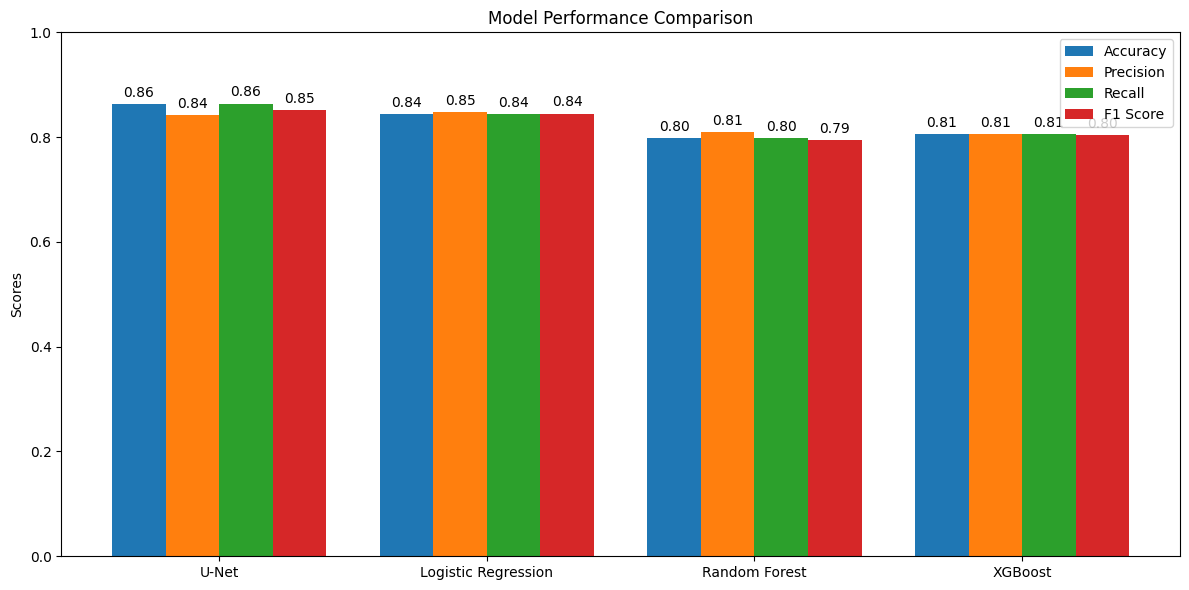

In [ ]:
#Evaluate  Models
print("\n Evaluating Models ")

results = []

# Evaluate U-Net
print("\nEvaluating U-Net...")
unet_result = eval_unet()
unet_result['model'] = 'U-Net'
results.append(unet_result)

# Evaluate other Models
print("\nEvaluating Other Models...")
for res in friend_results: # Iterate through result of other models
  results.append(res)


# Print Final Metrics
print("\nFinal metrics (validation set):")
for r in results:
    print(f"{r['model']}: Acc={r['accuracy']:.4f}, Prec={r['precision']:.4f}, Rec={r['recall']:.4f}, F1={r['f1']:.4f}")

# Plot Comparison Graph
labels = [r['model'] for r in results]
accuracy = [r['accuracy'] for r in results]
precision = [r['precision'] for r in results]
recall = [r['recall'] for r in results]
f1 = [r['f1'] for r in results]

x = np.arange(len(labels))  # label positions
width = 0.2  # bar width

fig, ax = plt.subplots(figsize=(12, 6)) # figure size barabo for better readability
rects1 = ax.bar(x - 1.5*width, accuracy, width, label='Accuracy')
rects2 = ax.bar(x - 0.5*width, precision, width, label='Precision')
rects3 = ax.bar(x + 0.5*width, recall, width, label='Recall')
rects4 = ax.bar(x + 1.5*width, f1, width, label='F1 Score')

ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.ylim(0, 1.0)

# Show values on bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

for bars in [rects1, rects2, rects3, rects4]:
    autolabel(bars)

plt.tight_layout()
plt.show()

 Evaluating U-Net. . . 
Accuracy: 0.8636
Precision: 0.8428
Recall: 0.8639
F1-score: 0.8524
Dice Score (Segmentation): 0.7263

Final metrics (val):
U-Net: Acc=0.8636, Prec=0.8428, Rec=0.8639, F1=0.8524
Logistic Regression: Acc=0.8442, Prec=0.8478, Rec=0.8442, F1=0.8448
Random Forest: Acc=0.7987, Prec=0.8089, Rec=0.7987, F1=0.7939
XGBoost: Acc=0.8052, Prec=0.8057, Rec=0.8052, F1=0.8044


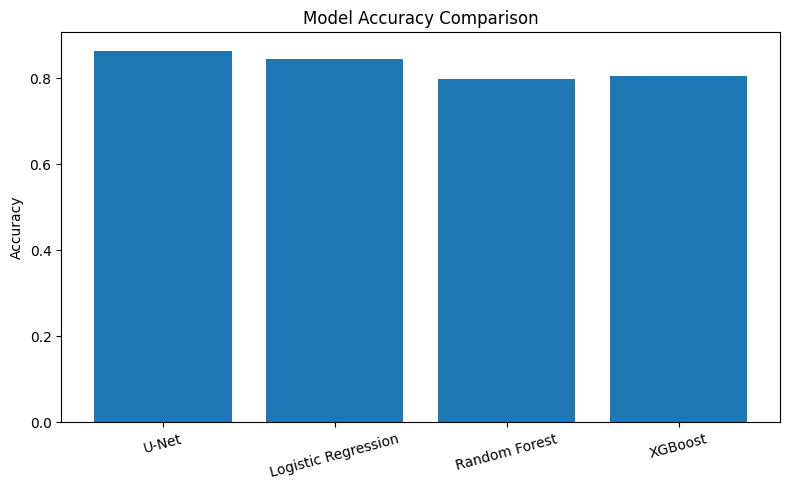

In [ ]:
# Only accuracy Plot
results = []

# Add U-Net result
unet_result = eval_unet()
unet_result['model'] = 'U-Net'
results.append(unet_result)

# Add other model results
for res in friend_results:
  results.append(res)

print("\nFinal metrics (val):")
for r in results:
    print(f"{r['model']}: Acc={r['accuracy']:.4f}, Prec={r['precision']:.4f}, Rec={r['recall']:.4f}, F1={r['f1']:.4f}")

# Plot simple accuracy comparison
models = [r['model'] for r in results]
accs = [r['accuracy'] for r in results]

plt.figure(figsize=(8,5))
plt.bar(models, accs)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()